In [16]:
import pandas as pd
import numpy as np

train_df = pd.read_parquet(
    "../data/processed/unified_train_all_features.parquet"
)

val_df = pd.read_parquet(
    "../data/processed/unified_validation_all_features.parquet"
)

test_df = pd.read_parquet(
    "../data/processed/unified_test_all_features.parquet"
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (27326, 29)
Validation: (5839, 29)
Test: (5801, 29)


In [5]:
feature_columns = [
    "has_context",
    "question_length",
    "answer_length",
    "context_length",

    "entity_count",
    "person_count",
    "organization_count",
    "location_count",
    "date_count",

    "question_answer_similarity",
    "question_context_similarity",
    "answer_context_similarity",

    "retrieval_top1_similarity",
    "retrieval_top3_mean_similarity",
    "retrieval_coverage",

    "answer_length_normalized",
    "feature_disagreement",

    "has_qa_similarity",
    "has_context_similarity"
]

In [6]:
print("Number of features:", len(feature_columns))

Number of features: 19


In [7]:
feature_columns = [
    "has_context",
    "question_length",
    "answer_length",
    "context_length",

    "entity_count",
    "person_count",
    "organization_count",
    "location_count",
    "date_count",

    "question_answer_similarity",
    "question_context_similarity",
    "answer_context_similarity",

    "retrieval_top1_similarity",
    "retrieval_top3_mean_similarity",
    "retrieval_coverage",

    "answer_length_normalized",
    "feature_disagreement",

    "has_qa_similarity"
]

print("Number of features:", len(feature_columns))

Number of features: 18


In [8]:
print(train_df.columns.tolist())

['question_id', 'candidate_id', 'source_dataset', 'question', 'answer', 'context', 'label', 'question_category', 'split', 'has_context', 'question_length', 'answer_length', 'context_length', 'entity_count', 'person_count', 'organization_count', 'location_count', 'date_count', 'question_answer_similarity', 'question_context_similarity', 'answer_context_similarity', 'retrieval_corpus', 'retrieval_top1_similarity', 'retrieval_top3_mean_similarity', 'retrieval_coverage', 'answer_length_normalized', 'semantic_uncertainty', 'retrieval_uncertainty', 'feature_disagreement']


In [17]:
feature_columns = [
    "has_context",
    "question_length",
    "answer_length",
    "context_length",

    "entity_count",
    "person_count",
    "organization_count",
    "location_count",
    "date_count",

    "question_answer_similarity",
    "question_context_similarity",
    "answer_context_similarity",

    "retrieval_top1_similarity",
    "retrieval_top3_mean_similarity",
    "retrieval_coverage",

    "answer_length_normalized",
    "feature_disagreement"
]

print("Number of features:", len(feature_columns))

Number of features: 17


In [11]:
missing = [
    col for col in feature_columns
    if col not in train_df.columns
]

print("Missing features:", missing)

Missing features: []


In [12]:
print("Missing in val:",
      [c for c in feature_columns if c not in val_df.columns])

print("Missing in test:",
      [c for c in feature_columns if c not in test_df.columns])

Missing in val: []
Missing in test: []


In [19]:
X_train = train_df[feature_columns].copy()
X_val = val_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = train_df["label"].astype(int)
y_val = val_df["label"].astype(int)
y_test = test_df["label"].astype(int)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (27326, 17)
X_val: (5839, 17)
X_test: (5801, 17)


In [14]:
%pip install xgboost==3.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/2.3 MB ? eta -:--:--0m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 22.2 MB/s  0:00:00

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [15]:
from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)

In [21]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_imp,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [22]:
xgb_model.fit(
    X_train_imp,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [23]:
val_prob_xgb = xgb_model.predict_proba(
    X_val_imp
)[:, 1]

test_prob_xgb = xgb_model.predict_proba(
    X_test_imp
)[:, 1]

test_pred_xgb = (
    test_prob_xgb >= 0.5
).astype(int)

In [24]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)

print("Test AUROC:",
      roc_auc_score(y_test, test_prob_xgb))

print("Test AUPRC:",
      average_precision_score(y_test, test_prob_xgb))

print("Accuracy:",
      accuracy_score(y_test, test_pred_xgb))

print("Precision:",
      precision_score(y_test, test_pred_xgb))

print("Recall:",
      recall_score(y_test, test_pred_xgb))

print("F1:",
      f1_score(y_test, test_pred_xgb))

print("Brier:",
      brier_score_loss(y_test, test_prob_xgb))

Test AUROC: 0.8955333475971424
Test AUPRC: 0.9036900957512263
Accuracy: 0.7955524909498363
Precision: 0.7765237020316027
Recall: 0.8300586004825922
F1: 0.8023992002665779
Brier: 0.1310519427061081


In [25]:
for dataset_name in test_df["source_dataset"].unique():

    mask = (
        test_df["source_dataset"] == dataset_name
    ).to_numpy()

    y_true_dataset = y_test.to_numpy()[mask]
    y_prob_dataset = test_prob_xgb[mask]

    print("\nDataset:", dataset_name)

    print(
        "AUROC:",
        roc_auc_score(y_true_dataset, y_prob_dataset)
    )

    print(
        "AUPRC:",
        average_precision_score(
            y_true_dataset,
            y_prob_dataset
        )
    )


Dataset: truthfulqa
AUROC: 0.6617938695034161
AUPRC: 0.652134664092866

Dataset: halueval
AUROC: 0.9843208888888887
AUPRC: 0.9872513695413536

Dataset: fever
AUROC: 0.6722886958762778
AUPRC: 0.6414177043202572


In [26]:
def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=10
):
    bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (
                (y_prob >= bins[i]) &
                (y_prob <= bins[i + 1])
            )
        else:
            mask = (
                (y_prob >= bins[i]) &
                (y_prob < bins[i + 1])
            )

        if not np.any(mask):
            continue

        bin_accuracy = np.mean(
            y_true[mask]
        )

        bin_confidence = np.mean(
            y_prob[mask]
        )

        bin_fraction = np.mean(mask)

        ece += (
            bin_fraction
            * abs(
                bin_accuracy -
                bin_confidence
            )
        )

    return ece

In [27]:
xgb_ece = expected_calibration_error(
    y_test.to_numpy(),
    test_prob_xgb
)

print("XGBoost ECE:", xgb_ece)

XGBoost ECE: 0.016437337427966613


In [29]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 12.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 6.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 8.2 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


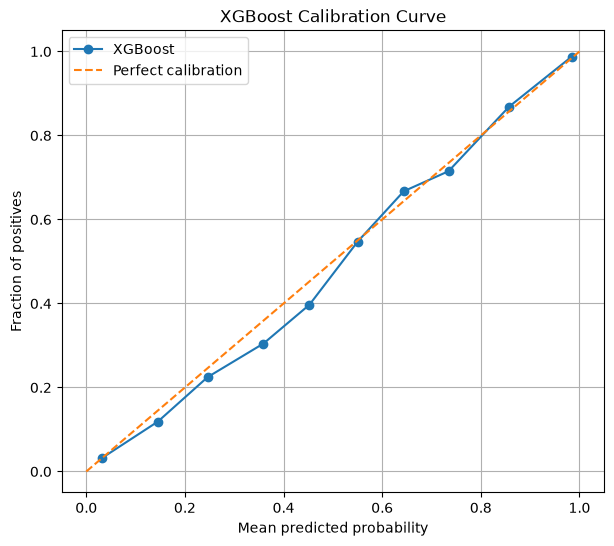

In [30]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fraction_of_positives, mean_predicted_value = (
    calibration_curve(
        y_test,
        test_prob_xgb,
        n_bins=10,
        strategy="uniform"
    )
)

plt.figure(figsize=(7, 6))

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("XGBoost Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": xgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(
    importance.to_string(index=False)
)

                       feature  importance
                   has_context    0.573875
                 answer_length    0.166570
      answer_length_normalized    0.066290
                context_length    0.036627
    question_answer_similarity    0.027544
     answer_context_similarity    0.018024
               question_length    0.016015
                    date_count    0.014225
retrieval_top3_mean_similarity    0.012239
                  person_count    0.010752
                  entity_count    0.010483
            retrieval_coverage    0.008899
     retrieval_top1_similarity    0.008766
          feature_disagreement    0.008430
   question_context_similarity    0.007903
                location_count    0.006885
            organization_count    0.006474


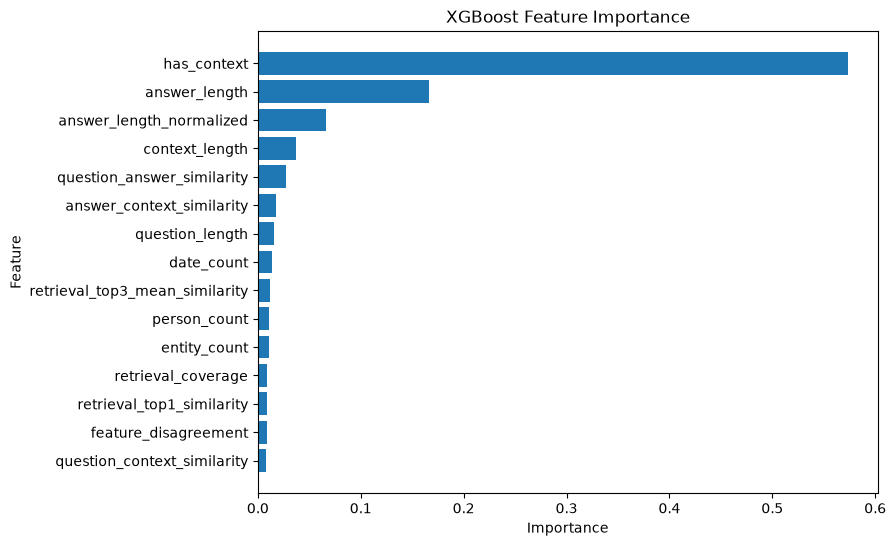

In [34]:
top_features = importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.show()

In [35]:
context_sensitive_features = [
    "has_context",
    "context_length",
    "question_context_similarity",
    "answer_context_similarity"
]

ablation_features = [
    f for f in feature_columns
    if f not in context_sensitive_features
]

print("Original features:", len(feature_columns))
print("Ablation features:", len(ablation_features))
print(ablation_features)

Original features: 17
Ablation features: 13
['question_length', 'answer_length', 'entity_count', 'person_count', 'organization_count', 'location_count', 'date_count', 'question_answer_similarity', 'retrieval_top1_similarity', 'retrieval_top3_mean_similarity', 'retrieval_coverage', 'answer_length_normalized', 'feature_disagreement']


In [36]:
X_train_ab = train_df[ablation_features].copy()
X_val_ab = val_df[ablation_features].copy()
X_test_ab = test_df[ablation_features].copy()

imputer_ab = SimpleImputer(strategy="median")

X_train_ab = imputer_ab.fit_transform(X_train_ab)
X_val_ab = imputer_ab.transform(X_val_ab)
X_test_ab = imputer_ab.transform(X_test_ab)

In [37]:
xgb_ablation = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_ablation.fit(
    X_train_ab,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [38]:
ablation_prob = xgb_ablation.predict_proba(
    X_test_ab
)[:, 1]

In [39]:
print(
    "Ablation AUROC:",
    roc_auc_score(y_test, ablation_prob)
)

print(
    "Ablation AUPRC:",
    average_precision_score(
        y_test,
        ablation_prob
    )
)

Ablation AUROC: 0.8812946189779982
Ablation AUPRC: 0.8890449969050069


In [40]:
for dataset_name in test_df["source_dataset"].unique():

    mask = (
        test_df["source_dataset"] == dataset_name
    ).to_numpy()

    y_true_dataset = y_test.to_numpy()[mask]
    y_prob_dataset = ablation_prob[mask]

    print("\nDataset:", dataset_name)

    print(
        "AUROC:",
        roc_auc_score(
            y_true_dataset,
            y_prob_dataset
        )
    )

    print(
        "AUPRC:",
        average_precision_score(
            y_true_dataset,
            y_prob_dataset
        )
    )


Dataset: truthfulqa
AUROC: 0.5936081434270255
AUPRC: 0.6124817158714021

Dataset: halueval
AUROC: 0.976424
AUPRC: 0.9804007894776607

Dataset: fever
AUROC: 0.6645784101608045
AUPRC: 0.637960134214065
